In [60]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.tensorboard import SummaryWriter
from matplotlib.ticker import MaxNLocator

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

import pickle
import seaborn as sns
import os
sns.set()



In [61]:
# Current path
current_path = os.path.abspath('')
print(current_path)
# Path to data
data_path = os.path.join(current_path, 'data')



/home/cognitia/Desktop/Work/PhD/PIAE-SDE/data_manipulation


In [62]:
location_mapping = {}
location_mapping['redmere_1'] = (52.5, 0.37)
location_mapping['woodwalton'] = (52.413, -0.2108421)
location_mapping['redmere_2'] = (52.5, 0.37)
location_mapping['great_fen'] = (52.484, -0.180)
location_mapping['wicken_fen'] = (52.309, 0.299)
location_mapping['rosedene'] = (52.533, 0.480)

data1 = pd.read_parquet("./other_sites/redmere_1/data.parquet")
data2 = pd.read_parquet("./other_sites/redmere_2/data.parquet")
data3 = pd.read_parquet("./other_sites/great_fen/data.parquet")
data4 = pd.read_parquet("./other_sites/wicken_fen/data.parquet")
data5 = pd.read_parquet("./other_sites/woodwalton/data.parquet")
data6 = pd.read_parquet("./complete_data.parquet")

def lat_lon_to_unit_vector(lat_deg, lon_deg):
    """
    Converts latitude and longitude in degrees to a 3D unit vector (x, y, z)
    on the surface of the Earth sphere.

    Args:
        lat_deg (float): Latitude in degrees (-90 to 90)
        lon_deg (float): Longitude in degrees (-180 to 180)

    Returns:
        tuple: (x, y, z) coordinates on the unit sphere
    """
    lat_rad = np.deg2rad(lat_deg)
    lon_rad = np.deg2rad(lon_deg)

    x = np.cos(lat_rad) * np.cos(lon_rad)
    y = np.cos(lat_rad) * np.sin(lon_rad)
    z = np.sin(lat_rad)

    return x, y, z


def add_site_vector(df: pd.DataFrame, lat_deg: float, lon_deg: float) -> pd.DataFrame:
    """
    Return a copy of *df* with site_x, site_y, site_z columns added, containing
    the 3‑D unit‑sphere coordinates for the given latitude and longitude.
    """
    x, y, z = lat_lon_to_unit_vector(lat_deg, lon_deg)
    return df.assign(site_x=x, site_y=y, site_z=z)

# Apply per‑site
data1 = add_site_vector(data1, *location_mapping["redmere_1"])
data1["site_name"] = "redmere_1"
data2 = add_site_vector(data2, *location_mapping["redmere_2"])
data2["site_name"] = "redmere_2"
data3 = add_site_vector(data3, *location_mapping["great_fen"])
data3["site_name"] = "great_fen"
data4 = add_site_vector(data4, *location_mapping["wicken_fen"])
data4["site_name"] = "wicken_fen"
data5 = add_site_vector(data5, *location_mapping["woodwalton"])
data5["site_name"] = "woodwalton"
data6 = add_site_vector(data6, *location_mapping["rosedene"])
data6["site_name"] = "rosedene"



In [63]:
# check count of -9999 in data in NEE
print((data1['NEE'] == -9999).sum())
print((data2['NEE'] == -9999).sum())
print((data3['NEE'] == -9999).sum())
print((data4['NEE'] == -9999).sum())
print((data5['NEE'] == -9999).sum())
print((data6['NEE'] == -9999).sum())

16774
24999
10528
15304
13816
69882


In [64]:
def analyze_gap_lengths(df, column='NEE', missing_value=-9999):
    """
    Analyze consecutive missing values in a dataframe column.
    
    Returns:
        gap_lengths: list of consecutive missing value counts
    """
    is_missing = (df[column] == missing_value).values
    gap_lengths = []
    current_gap = 0
    
    for missing in is_missing:
        if missing:
            current_gap += 1
        else:
            if current_gap > 0:
                gap_lengths.append(current_gap)
                current_gap = 0
    
    # Don't forget the last gap if data ends with missing values
    if current_gap > 0:
        gap_lengths.append(current_gap)
    
    return gap_lengths

# Define consistent color mapping for all sites
SITE_COLORS = {
    'Great Fen': '#008080',      # Teal
    'Redmere 1': '#9370DB',      # Purple
    'Redmere 2': '#4B0082',      # Indigo
    'Rosedene': '#228B22'        # Forest Green
}

# Analyze gaps for selected datasets (Redmere 1, Redmere 2, Great Fen, Rosedene)
datasets = {
    'Redmere 1': data1,
    'Redmere 2': data2,
    'Great Fen': data3,
    'Rosedene': data6
}

gap_data = {}
for name, df in datasets.items():
    gap_lengths = analyze_gap_lengths(df)
    gap_data[name] = gap_lengths
    max_gap = max(gap_lengths) if gap_lengths else 0
    max_days = max_gap * 0.5 / 24  # Convert half-hourly records to days
    print(f"{name}: {len(gap_lengths):,} gaps, max gap length: {max_gap:,} records ({max_days:.2f} days)")


Redmere 1: 2,649 gaps, max gap length: 379 records (7.90 days)
Redmere 2: 2,862 gaps, max gap length: 419 records (8.73 days)
Great Fen: 2,428 gaps, max gap length: 405 records (8.44 days)
Rosedene: 8,619 gaps, max gap length: 815 records (16.98 days)


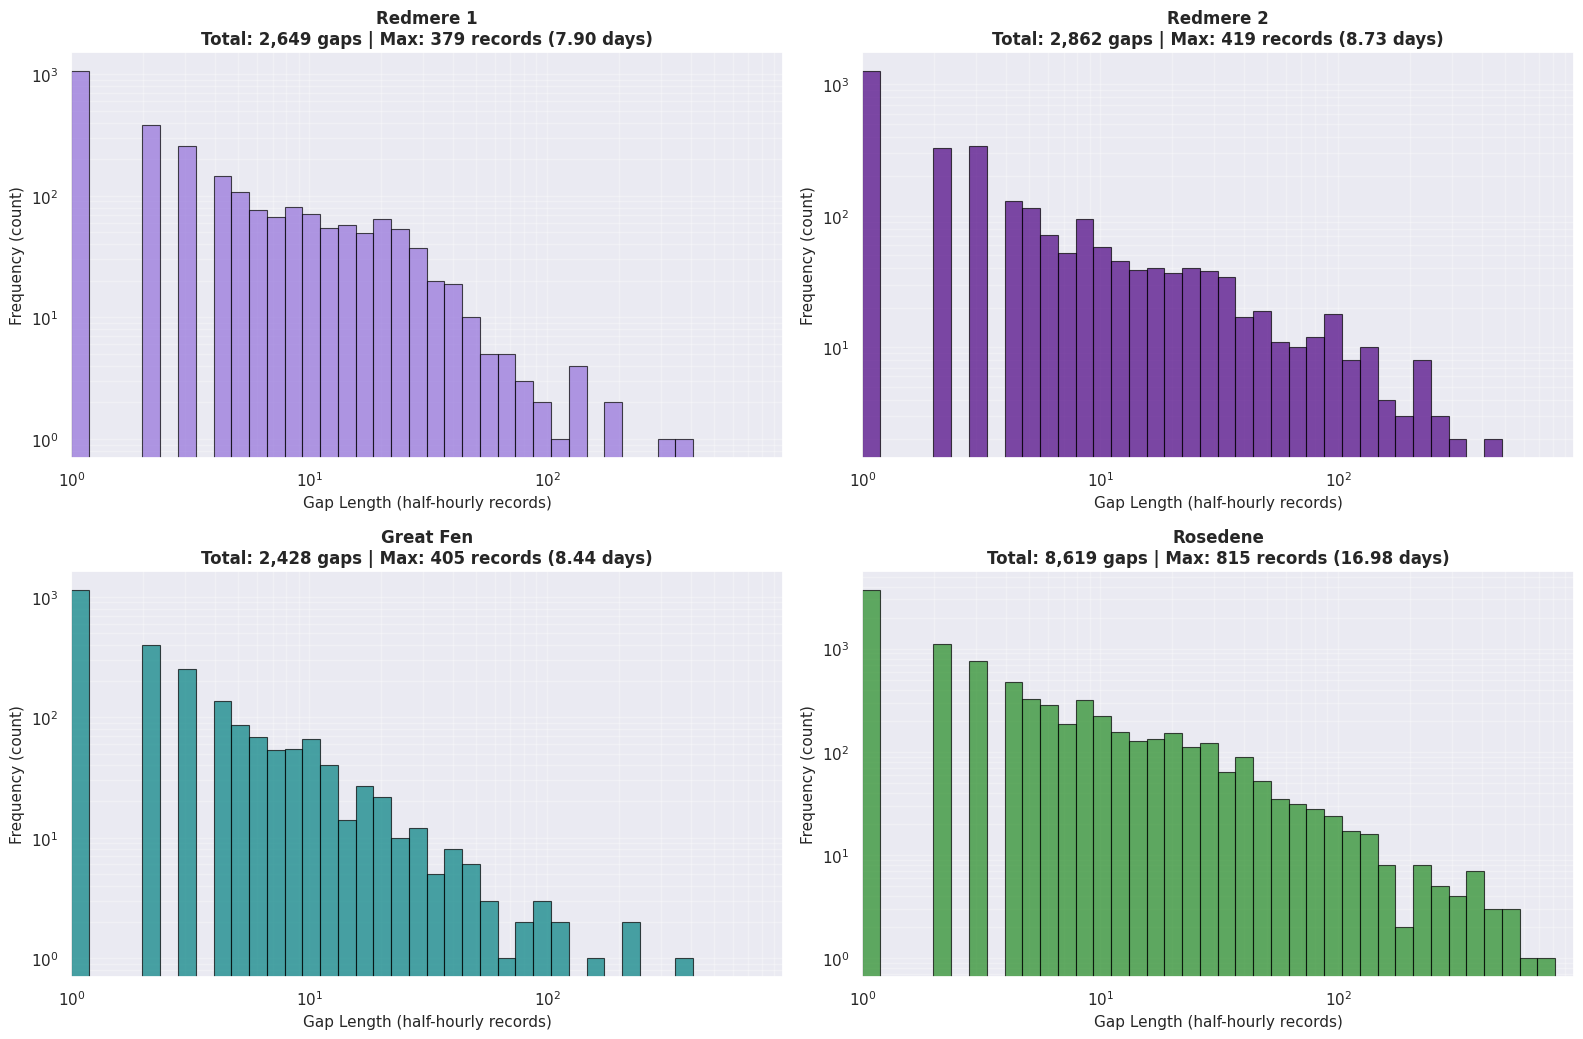


GAP LENGTH STATISTICS (1 record = 30 minutes)

Redmere 1:
  Number of gaps: 2,649
  Total missing records: 16,774 (349.5 days)
  Mean gap length: 6.33 records (3.2 hours)
  Median gap length: 2.00 records
  Max gap length: 379 records (7.90 days)
  Min gap length: 1 records

Redmere 2:
  Number of gaps: 2,862
  Total missing records: 24,999 (520.8 days)
  Mean gap length: 8.73 records (4.4 hours)
  Median gap length: 2.00 records
  Max gap length: 419 records (8.73 days)
  Min gap length: 1 records

Great Fen:
  Number of gaps: 2,428
  Total missing records: 10,528 (219.3 days)
  Mean gap length: 4.34 records (2.2 hours)
  Median gap length: 2.00 records
  Max gap length: 405 records (8.44 days)
  Min gap length: 1 records

Rosedene:
  Number of gaps: 8,619
  Total missing records: 69,882 (1455.9 days)
  Mean gap length: 8.11 records (4.1 hours)
  Median gap length: 2.00 records
  Max gap length: 815 records (16.98 days)
  Min gap length: 1 records


In [73]:
# Plot histograms of gap lengths for all sites
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.flatten()

# Find global max for consistent x-axis
global_max_gap = max([max(gaps) if gaps else 1 for gaps in gap_data.values()])

for idx, (name, gaps) in enumerate(gap_data.items()):
    ax = axes[idx]
    if gaps:
        # Use log-spaced bins with base ~1.8 for better tail visualization
        bins = np.logspace(0, np.log10(global_max_gap), 40, base=10)
        ax.hist(gaps, bins=bins, color=SITE_COLORS[name], edgecolor='black', 
                alpha=0.7, linewidth=0.8)
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel('Gap Length (half-hourly records)', fontsize=11)
        ax.set_ylabel('Frequency (count)', fontsize=11)
        max_days = max(gaps) * 0.5 / 24
        ax.set_title(f'{name}\nTotal: {len(gaps):,} gaps | Max: {max(gaps):,} records ({max_days:.2f} days)', 
                     fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3, which='both')
        ax.set_xlim(1, global_max_gap * 1.2)
    else:
        ax.text(0.5, 0.5, 'No gaps', ha='center', va='center', fontsize=14)
        ax.set_title(name, fontsize=12, fontweight='bold')


plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig('gap_length_histograms.png', dpi=300, bbox_inches='tight')
plt.show()

# Print statistics with operational context
print("\n" + "="*90)
print("GAP LENGTH STATISTICS (1 record = 30 minutes)")
print("="*90)
for name, gaps in gap_data.items():
    if gaps:
        total_records = sum(gaps)
        max_gap = max(gaps)
        mean_gap = np.mean(gaps)
        print(f"\n{name}:")
        print(f"  Number of gaps: {len(gaps):,}")
        print(f"  Total missing records: {total_records:,} ({total_records * 0.5 / 24:.1f} days)")
        print(f"  Mean gap length: {mean_gap:.2f} records ({mean_gap * 0.5:.1f} hours)")
        print(f"  Median gap length: {np.median(gaps):.2f} records")
        print(f"  Max gap length: {max_gap:,} records ({max_gap * 0.5 / 24:.2f} days)")
        print(f"  Min gap length: {min(gaps):,} records")
print("="*90)


In [66]:
# Define time scale categories (in half-hourly records)
# Assuming half-hourly data: 48 records/day, 336 records/week, ~1440 records/month, ~4320 records/quarter
time_scales = {
    'Half-hourly (< 1 hr)': (0, 2),           # Less than 1 hour (< 2 records)
    'Hourly to Daily (1 hr - 1 day)': (2, 48),     # 1 hour to 1 day (2-48 records)
    'Daily to Weekly (1-7 days)': (48, 336), # 1 day to 1 week (48-336 records)
    'Weekly to Monthly (7-30 days)': (336, 1440), # 1 week to 1 month (336-1440 records)
    'Monthly to Quarterly (30-90 days)': (1440, 4320), # 1 month to 3 months (1440-4320 records)
    'Quarterly+ (> 90 days)': (4320, float('inf')) # More than 3 months (> 4320 records)
}

def categorize_gaps_by_timescale(gap_lengths, time_scales):
    """
    Categorize gap lengths into different time scales.
    
    Returns:
        dict: {category_name: [gap_lengths]}
    """
    categorized = {name: [] for name in time_scales.keys()}
    
    for gap in gap_lengths:
        for name, (min_val, max_val) in time_scales.items():
            if min_val <= gap < max_val:
                categorized[name].append(gap)
                break
    
    return categorized

# Categorize gaps for all sites
categorized_gaps = {}
for name, gaps in gap_data.items():
    categorized_gaps[name] = categorize_gaps_by_timescale(gaps, time_scales)

# Identify which categories have data across all sites
scale_names_all = list(time_scales.keys())
categories_with_data = []
for scale_name in scale_names_all:
    has_data = any(len(categorized_gaps[site][scale_name]) > 0 for site in datasets.keys())
    if has_data:
        categories_with_data.append(scale_name)

# Print categorized statistics (only for categories with data)
print("\n" + "="*90)
print("GAP ANALYSIS BY TIME SCALE (1 record = 30 minutes)")
print("="*90)
for site_name in datasets.keys():
    print(f"\n{site_name}:")
    for scale_name in categories_with_data:
        gaps = categorized_gaps[site_name][scale_name]
        if gaps:
            total_days = sum(gaps) * 0.5 / 24
            print(f"  {scale_name}:")
            print(f"    Count: {len(gaps):,} gaps")
            print(f"    Total records: {sum(gaps):,} ({total_days:.1f} days)")
            print(f"    Mean: {np.mean(gaps):.2f}, Median: {np.median(gaps):.2f}")
print("="*90)



GAP ANALYSIS BY TIME SCALE (1 record = 30 minutes)

Redmere 1:
  Half-hourly (< 1 hr):
    Count: 1,070 gaps
    Total records: 1,070 (22.3 days)
    Mean: 1.00, Median: 1.00
  Hourly to Daily (1 hr - 1 day):
    Count: 1,552 gaps
    Total records: 12,763 (265.9 days)
    Mean: 8.22, Median: 4.00
  Daily to Weekly (1-7 days):
    Count: 26 gaps
    Total records: 2,562 (53.4 days)
    Mean: 98.54, Median: 74.50
  Weekly to Monthly (7-30 days):
    Count: 1 gaps
    Total records: 379 (7.9 days)
    Mean: 379.00, Median: 379.00

Redmere 2:
  Half-hourly (< 1 hr):
    Count: 1,274 gaps
    Total records: 1,274 (26.5 days)
    Mean: 1.00, Median: 1.00
  Hourly to Daily (1 hr - 1 day):
    Count: 1,491 gaps
    Total records: 12,004 (250.1 days)
    Mean: 8.05, Median: 4.00
  Daily to Weekly (1-7 days):
    Count: 94 gaps
    Total records: 10,550 (219.8 days)
    Mean: 112.23, Median: 96.00
  Weekly to Monthly (7-30 days):
    Count: 3 gaps
    Total records: 1,171 (24.4 days)
    Mean:

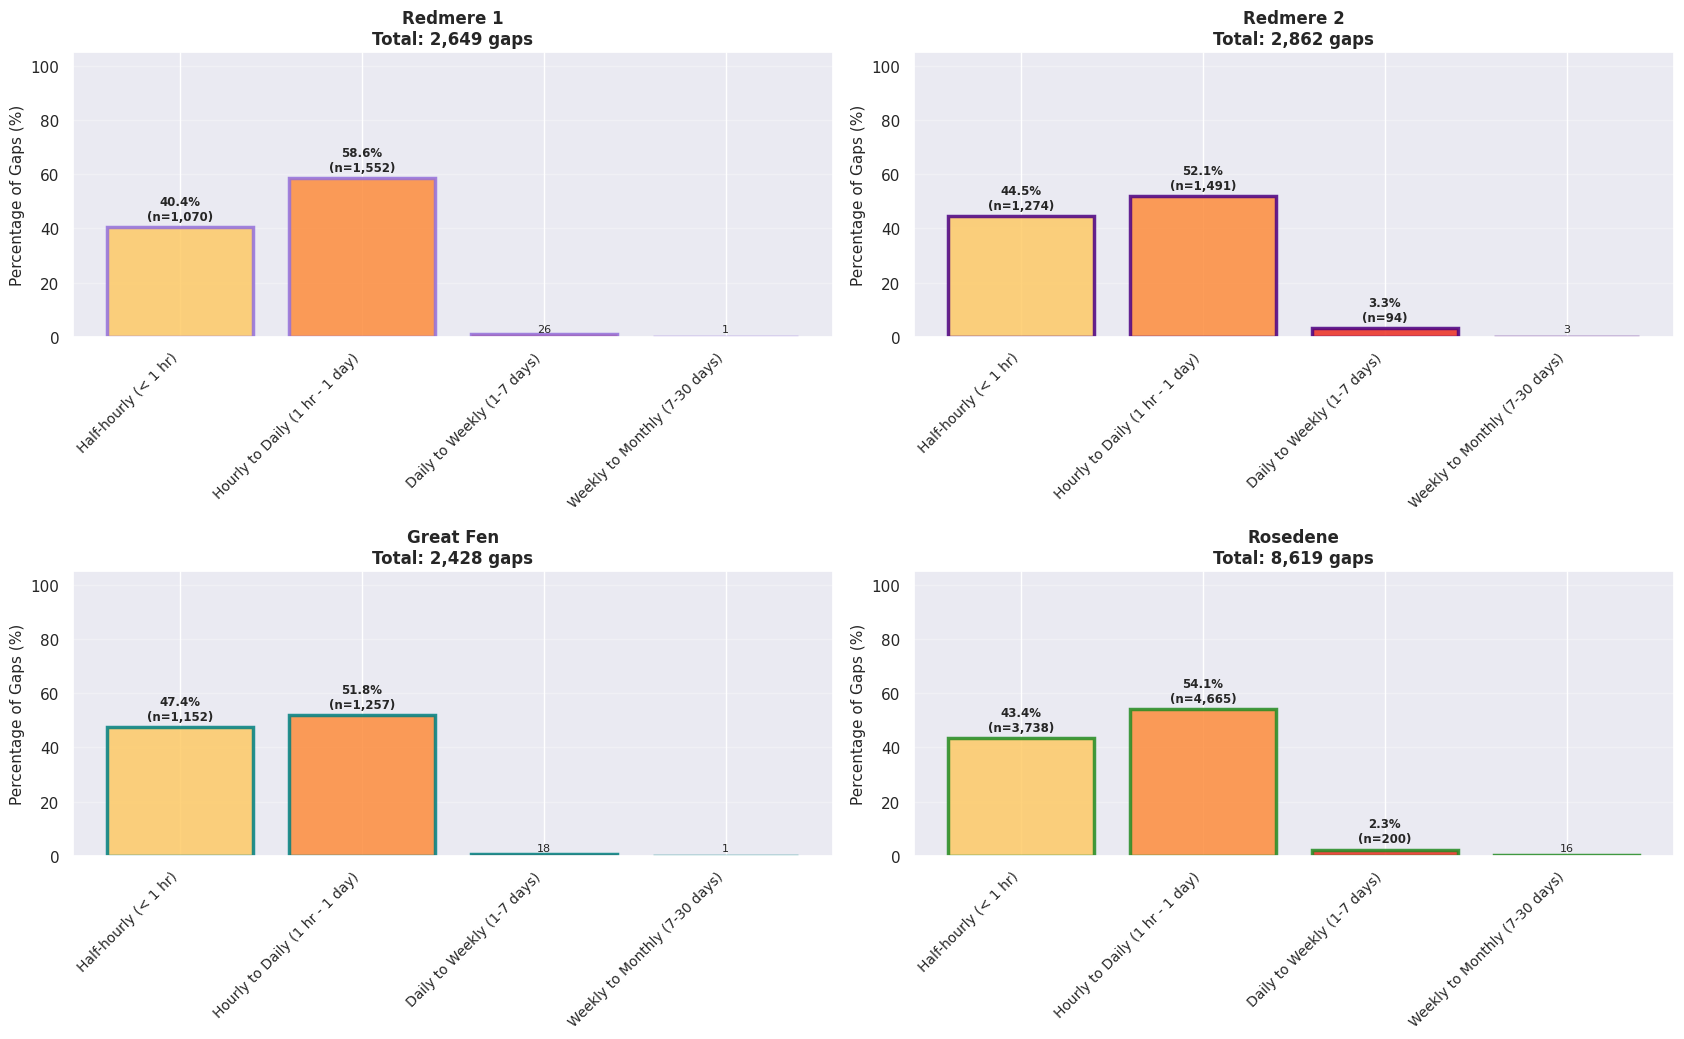

In [74]:
# Plot gap counts by time scale (as percentages)
fig, axes = plt.subplots(2, 2, figsize=(17, 11))
axes = axes.flatten()

# Define colors for time scale categories (only for categories with data)
timescale_colors = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(categories_with_data)))

for idx, (site_name, categorized) in enumerate(categorized_gaps.items()):
    ax = axes[idx]
    
    # Get counts only for categories with data
    scale_names = categories_with_data
    counts = [len(categorized[name]) for name in scale_names]
    total_gaps = sum(counts)
    
    # Calculate percentages
    percentages = [(count / total_gaps * 100) if total_gaps > 0 else 0 for count in counts]
    
    # Create bar plot with site-specific color as border
    bars = ax.bar(range(len(scale_names)), percentages, color=timescale_colors, 
                  edgecolor=SITE_COLORS[site_name], linewidth=2.5, alpha=0.85)
    ax.set_xticks(range(len(scale_names)))
    ax.set_xticklabels(scale_names, rotation=45, ha='right', fontsize=10)
    ax.set_ylabel('Percentage of Gaps (%)', fontsize=11)
    ax.set_title(f'{site_name}\nTotal: {total_gaps:,} gaps', fontsize=12, fontweight='bold')
    ax.set_ylim(0, 105)  # Consistent y-axis across sites
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add percentage labels on bars with better positioning
    for bar, pct, count in zip(bars, percentages, counts):
        if pct > 1:  # Only label if > 1%
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 1.5,
                   f'{pct:.1f}%\n(n={count:,})',
                   ha='center', va='bottom', fontsize=8.5, fontweight='bold')
        elif pct > 0:  # Very small percentages, just show count
            ax.text(bar.get_x() + bar.get_width()/2., 1,
                   f'{count:,}', ha='center', va='bottom', fontsize=8)


plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig('gap_counts_by_timescale.png', dpi=300, bbox_inches='tight')
plt.show()


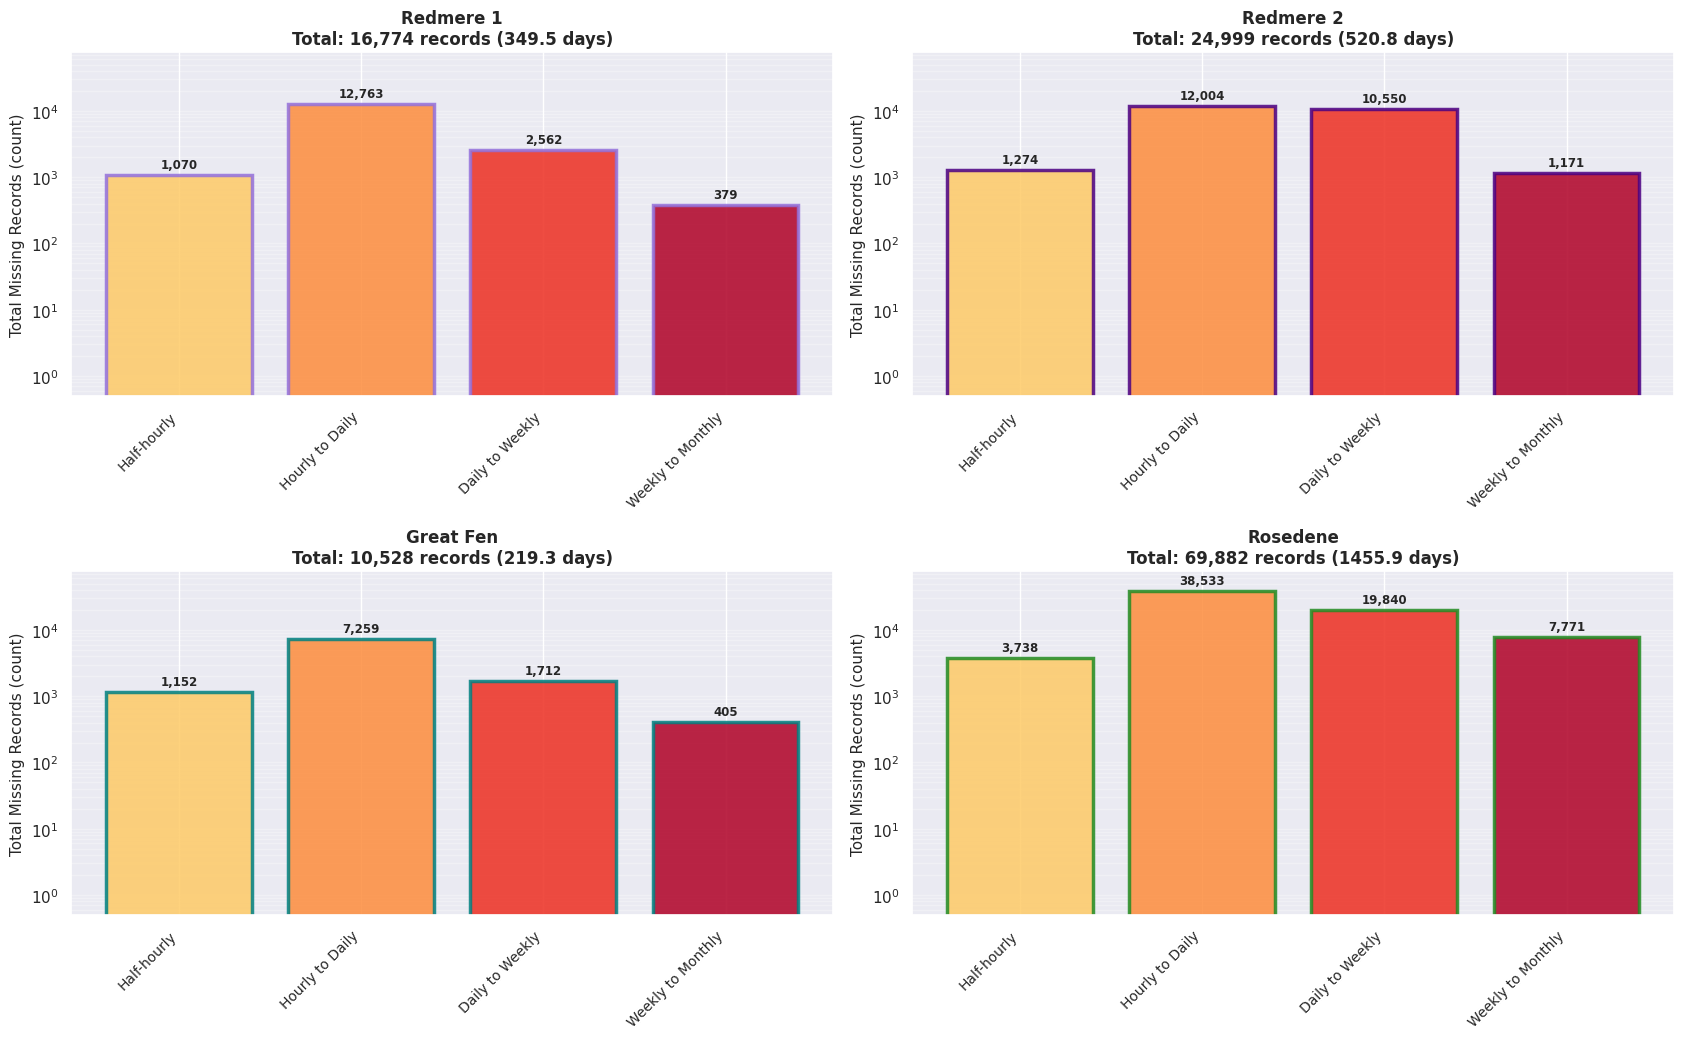

In [75]:
# Plot total missing records by time scale
fig, axes = plt.subplots(2, 2, figsize=(17, 11))
axes = axes.flatten()

# Find global max for consistent y-axis (only for categories with data)
all_totals = []
for categorized in categorized_gaps.values():
    for scale_name in categories_with_data:
        gaps = categorized[scale_name]
        if gaps:
            all_totals.append(sum(gaps))
global_max_records = max(all_totals) if all_totals else 1

# Define colors for time scale categories (only for categories with data)
timescale_colors = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(categories_with_data)))

for idx, (site_name, categorized) in enumerate(categorized_gaps.items()):
    ax = axes[idx]
    
    # Get total missing records only for categories with data
    scale_names = categories_with_data
    total_records = [sum(categorized[name]) for name in scale_names]
    
    # Create bar plot
    bars = ax.bar(range(len(scale_names)), total_records, color=timescale_colors,
                  edgecolor=SITE_COLORS[site_name], linewidth=2.5, alpha=0.85)
    ax.set_xticks(range(len(scale_names)))
    ax.set_xticklabels([name.split('(')[0].strip() for name in scale_names], 
                        rotation=45, ha='right', fontsize=10)
    ax.set_ylabel('Total Missing Records (count)', fontsize=11)
    total_days = sum(total_records) * 0.5 / 24
    ax.set_title(f'{site_name}\nTotal: {sum(total_records):,} records ({total_days:.1f} days)', 
                 fontsize=12, fontweight='bold')
    ax.set_yscale('log')
    ax.set_ylim(0.5, global_max_records * 2)  # Consistent y-axis
    ax.grid(True, alpha=0.3, axis='y', which='both')
    
    # Add count labels on bars with thousands separators
    for bar, total in zip(bars, total_records):
        if total > 0:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height * 1.15,
                   f'{total:,}',
                   ha='center', va='bottom', fontsize=8.5, fontweight='bold')


plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig('gap_total_records_by_timescale.png', dpi=300, bbox_inches='tight')
plt.show()


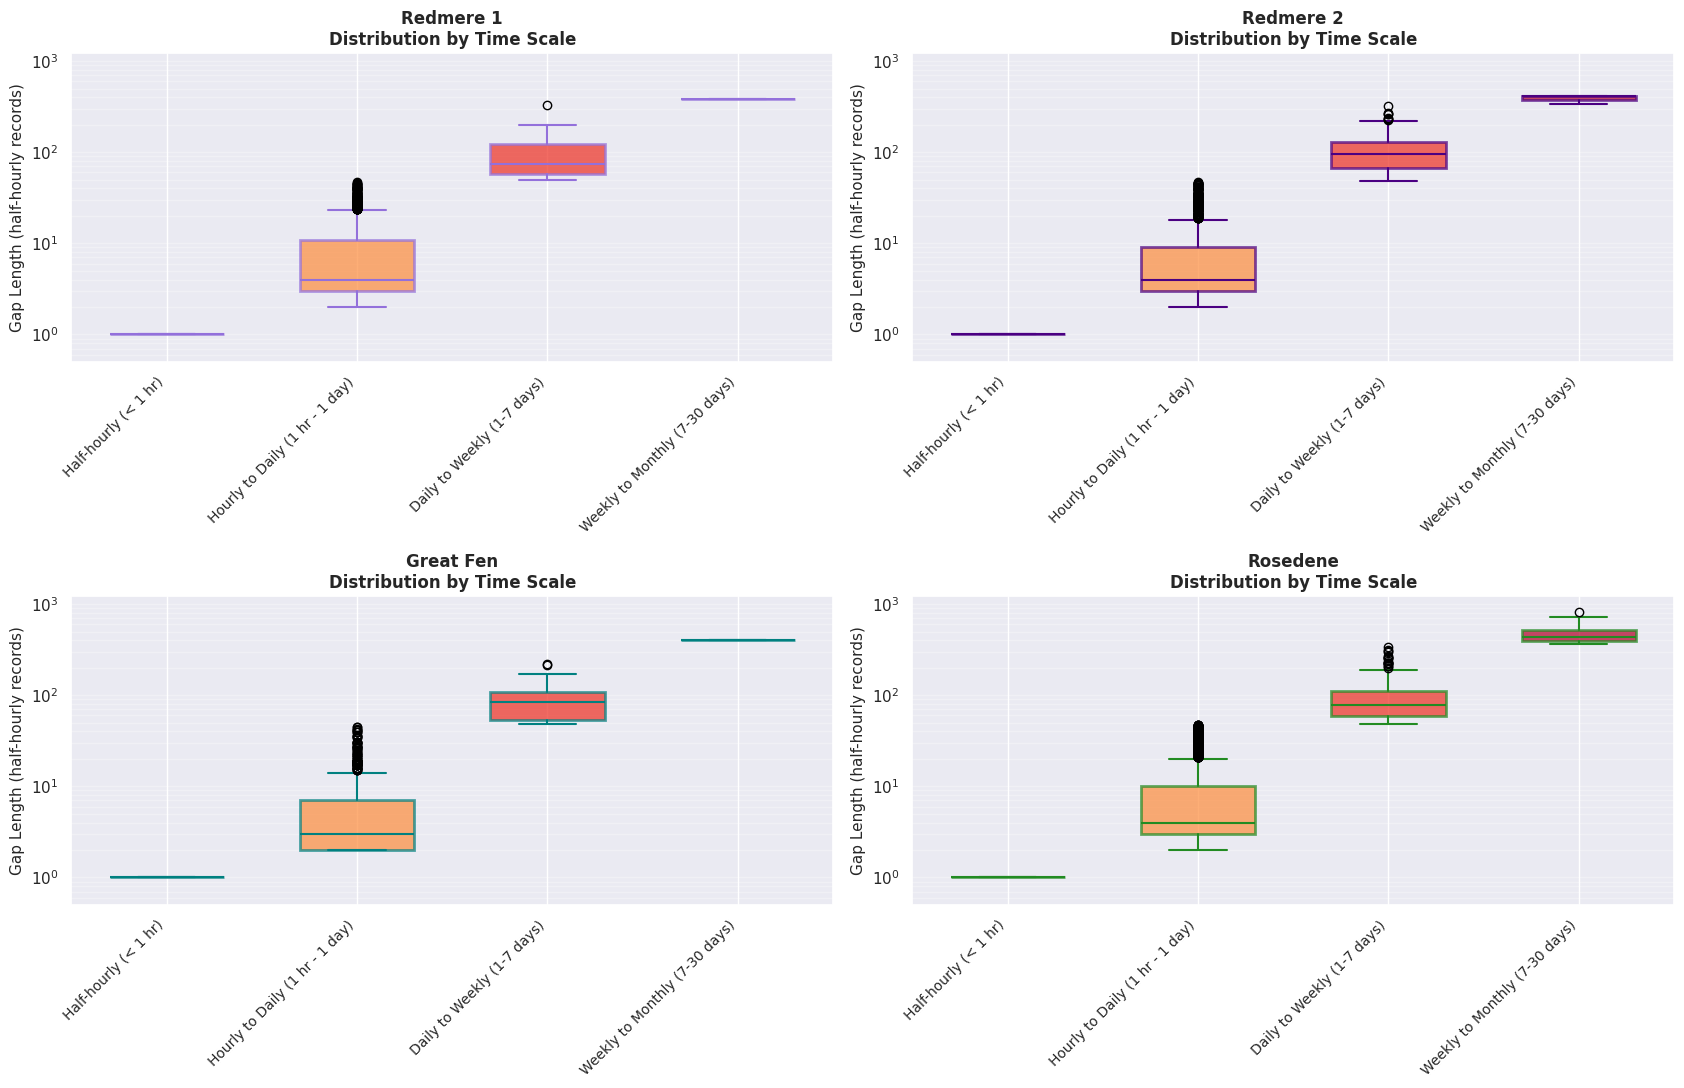

In [76]:
# Create detailed box plots for each time scale category
fig, axes = plt.subplots(2, 2, figsize=(17, 12))
axes = axes.flatten()

# Define colors for time scale categories (only for categories with data)
timescale_colors = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(categories_with_data)))

for idx, (site_name, categorized) in enumerate(categorized_gaps.items()):
    ax = axes[idx]
    
    # Prepare data for plotting (only for categories with data)
    data_to_plot = []
    labels_to_plot = []
    colors_to_plot = []
    
    for scale_idx, scale_name in enumerate(categories_with_data):
        gaps = categorized[scale_name]
        if len(gaps) > 0:
            data_to_plot.append(gaps)
            labels_to_plot.append(scale_name)
            colors_to_plot.append(timescale_colors[scale_idx])
    
    if data_to_plot:
        # Create box plot with individual points
        bp = ax.boxplot(data_to_plot, tick_labels=labels_to_plot, patch_artist=True, 
                        showfliers=True, widths=0.6)
        
        # Color the boxes with site-specific border
        for patch, color in zip(bp['boxes'], colors_to_plot):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
            patch.set_edgecolor(SITE_COLORS[site_name])
            patch.set_linewidth(2)
        
        # Style whiskers and medians with site color
        for element in ['whiskers', 'caps', 'medians']:
            for item in bp[element]:
                item.set_color(SITE_COLORS[site_name])
                item.set_linewidth(1.5)
        
        ax.set_yscale('log')
        ax.set_ylabel('Gap Length (half-hourly records)', fontsize=11)
        ax.set_title(f'{site_name}\nDistribution by Time Scale', 
                     fontsize=12, fontweight='bold')
        ax.tick_params(axis='x', rotation=45)
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=10)
        ax.grid(True, alpha=0.3, axis='y', which='both')
        ax.set_ylim(0.5, global_max_gap * 1.5)  # Consistent y-axis
    else:
        ax.text(0.5, 0.5, 'No gaps', ha='center', va='center', fontsize=14)
        ax.set_title(f'{site_name}', fontsize=12, fontweight='bold')

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig('gap_distribution_by_timescale.png', dpi=300, bbox_inches='tight')
plt.show()


In [70]:
# Create a comprehensive summary table
summary_data = []

for site_name in datasets.keys():
    site_gaps = gap_data[site_name]
    categorized = categorized_gaps[site_name]
    
    row = {
        'Site': site_name,
        'Total Gaps': len(site_gaps),
        'Total Missing Records': sum(site_gaps) if site_gaps else 0,
        'Mean Gap Length': np.mean(site_gaps) if site_gaps else 0,
        'Median Gap Length': np.median(site_gaps) if site_gaps else 0,
        'Max Gap Length': max(site_gaps) if site_gaps else 0,
    }
    
    # Add counts for each time scale (only for categories with data)
    for scale_name in categories_with_data:
        gaps_in_scale = categorized[scale_name]
        row[f'{scale_name} (count)'] = len(gaps_in_scale)
        row[f'{scale_name} (records)'] = sum(gaps_in_scale)
    
    summary_data.append(row)

summary_df = pd.DataFrame(summary_data)
print("\n" + "="*100)
print("COMPREHENSIVE GAP ANALYSIS SUMMARY")
print("="*100)
print(summary_df.to_string(index=False))
print("="*100)

# Save to CSV
summary_df.to_csv('gap_analysis_summary.csv', index=False)
print("\nSummary saved to: gap_analysis_summary.csv")



COMPREHENSIVE GAP ANALYSIS SUMMARY
     Site  Total Gaps  Total Missing Records  Mean Gap Length  Median Gap Length  Max Gap Length  Half-hourly (< 1 hr) (count)  Half-hourly (< 1 hr) (records)  Hourly to Daily (1 hr - 1 day) (count)  Hourly to Daily (1 hr - 1 day) (records)  Daily to Weekly (1-7 days) (count)  Daily to Weekly (1-7 days) (records)  Weekly to Monthly (7-30 days) (count)  Weekly to Monthly (7-30 days) (records)
Redmere 1        2649                  16774         6.332201                2.0             379                          1070                            1070                                    1552                                     12763                                  26                                  2562                                      1                                      379
Redmere 2        2862                  24999         8.734801                2.0             419                          1274                            1274                

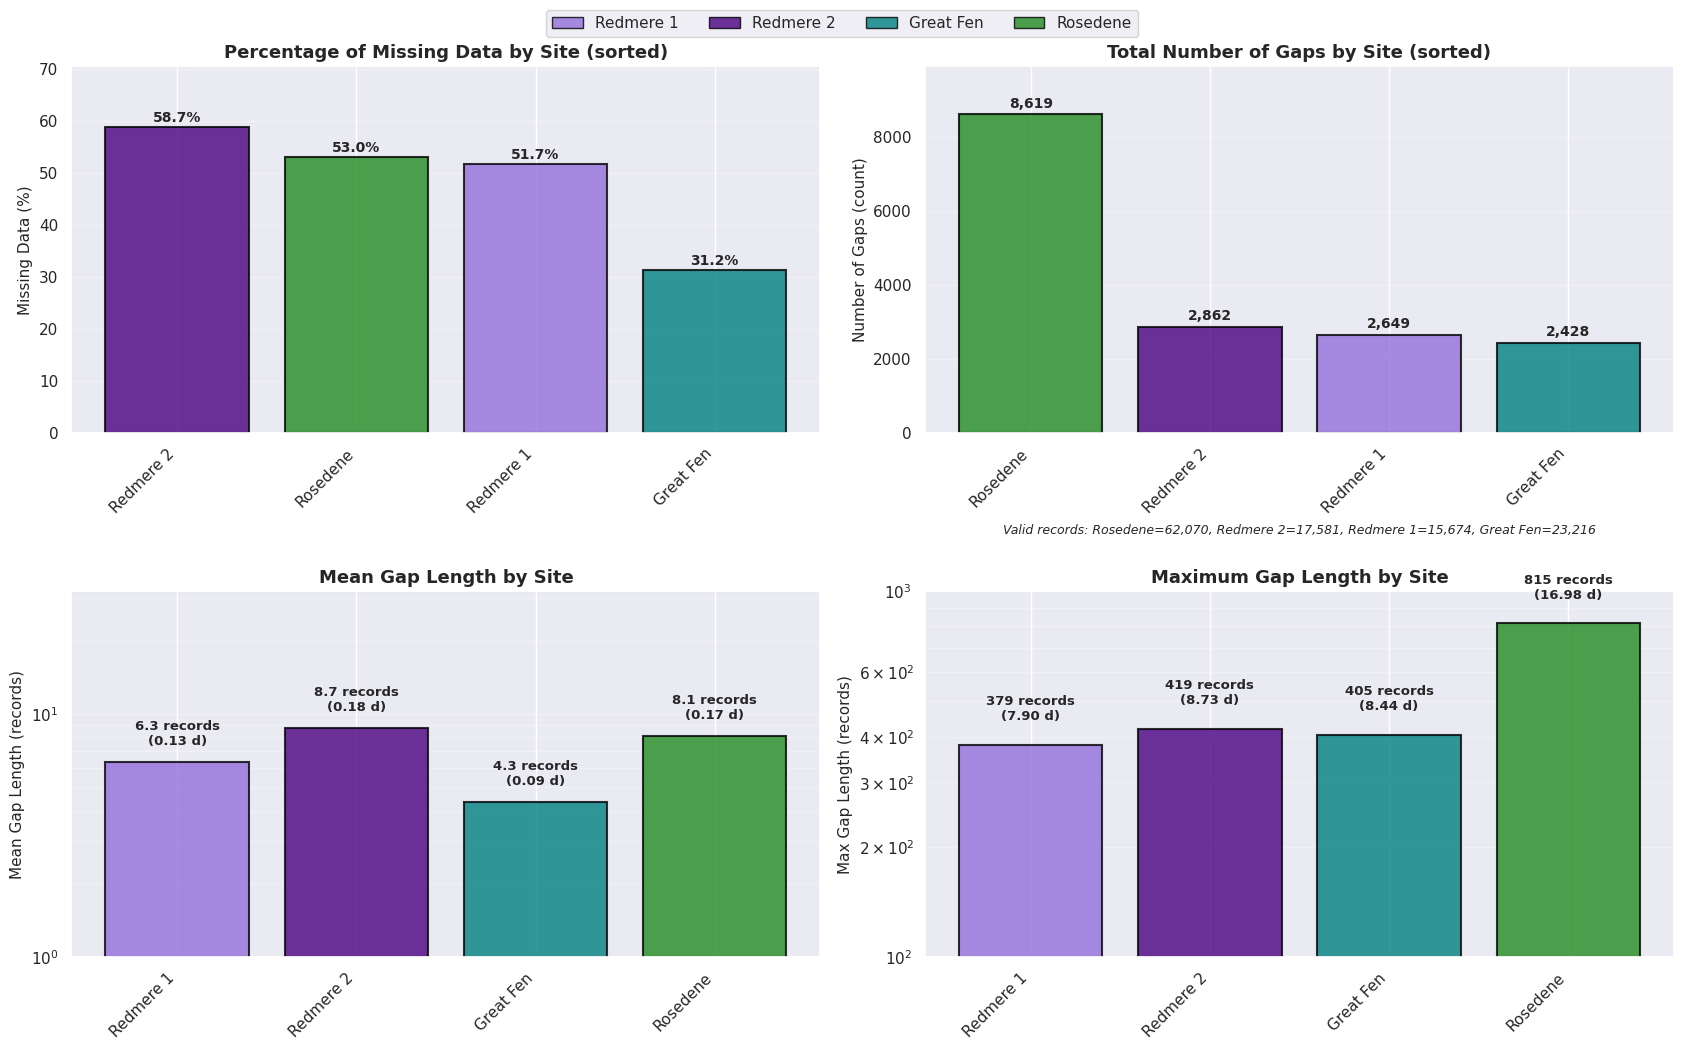

In [77]:
# Create comparison visualization across sites
fig, axes = plt.subplots(2, 2, figsize=(17, 12))

# Prepare base data
site_names = list(datasets.keys())
site_colors_list = [SITE_COLORS[name] for name in site_names]
site_lengths = {name: len(datasets[name]) for name in site_names}
site_missing = {name: sum(gap_data[name]) for name in site_names}

# 1. Missing data percentage (sorted desc)
ax1 = axes[0, 0]
missing_pct_items = [(name, 100 * site_missing[name] / site_lengths[name]) for name in site_names]
missing_pct_items.sort(key=lambda x: x[1], reverse=True)
sorted_names_pct = [n for n, _ in missing_pct_items]
sorted_values_pct = [v for _, v in missing_pct_items]
sorted_colors_pct = [SITE_COLORS[n] for n in sorted_names_pct]

bars = ax1.bar(range(len(sorted_names_pct)), sorted_values_pct, color=sorted_colors_pct,
               edgecolor='black', linewidth=1.5, alpha=0.8)
ax1.set_xticks(range(len(sorted_names_pct)))
ax1.set_xticklabels(sorted_names_pct, rotation=45, ha='right', fontsize=11)
ax1.set_ylabel('Missing Data (%)', fontsize=11)
ax1.set_title('Percentage of Missing Data by Site (sorted)', fontsize=13, fontweight='bold')
ax1.set_ylim(0, max(sorted_values_pct) * 1.2)
ax1.grid(True, alpha=0.3, axis='y')
for bar, pct in zip(bars, sorted_values_pct):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 2. Number of gaps (sorted desc) + valid records caption
ax2 = axes[0, 1]
gap_counts_items = [(name, len(gap_data[name])) for name in site_names]
gap_counts_items.sort(key=lambda x: x[1], reverse=True)
sorted_names_gaps = [n for n, _ in gap_counts_items]
sorted_values_gaps = [v for _, v in gap_counts_items]
sorted_colors_gaps = [SITE_COLORS[n] for n in sorted_names_gaps]

bars = ax2.bar(range(len(sorted_names_gaps)), sorted_values_gaps, color=sorted_colors_gaps,
               edgecolor='black', linewidth=1.5, alpha=0.8)
ax2.set_xticks(range(len(sorted_names_gaps)))
ax2.set_xticklabels(sorted_names_gaps, rotation=45, ha='right', fontsize=11)
ax2.set_ylabel('Number of Gaps (count)', fontsize=11)
ax2.set_title('Total Number of Gaps by Site (sorted)', fontsize=13, fontweight='bold')
ax2.set_ylim(0, max(sorted_values_gaps) * 1.15)
ax2.grid(True, alpha=0.3, axis='y')
for bar, count in zip(bars, sorted_values_gaps):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 100,
            f'{count:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Add caption below ax2 with valid record counts
valid_counts = {name: site_lengths[name] - site_missing[name] for name in site_names}
caption_text = 'Valid records: ' + ', '.join([f"{name}={valid_counts[name]:,}" for name in sorted_names_gaps])
ax2.text(0.5, -0.25, caption_text, transform=ax2.transAxes, ha='center', va='top', fontsize=9, style='italic')

# 3. Mean gap length (log) with fixed limits
ax3 = axes[1, 0]
mean_gap_lengths = [np.mean(gap_data[name]) if gap_data[name] else 0 for name in site_names]
mean_gap_days = [gap * 0.5 / 24 for gap in mean_gap_lengths]
bars = ax3.bar(range(len(site_names)), mean_gap_lengths, color=site_colors_list,
               edgecolor='black', linewidth=1.5, alpha=0.8)
ax3.set_xticks(range(len(site_names)))
ax3.set_xticklabels(site_names, rotation=45, ha='right', fontsize=11)
ax3.set_ylabel('Mean Gap Length (records)', fontsize=11)
ax3.set_title('Mean Gap Length by Site', fontsize=13, fontweight='bold')
ax3.set_yscale('log')
ax3.set_ylim(1, 32)  # Fixed across runs
ax3.grid(True, alpha=0.3, axis='y', which='both')
for bar, mean_val, days in zip(bars, mean_gap_lengths, mean_gap_days):
    if mean_val > 0:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height * 1.15,
                f'{mean_val:.1f} records\n({days:.2f} d)',
                ha='center', va='bottom', fontsize=9.5, fontweight='bold')

# 4. Max gap length (log) with fixed [1e2, 1e3]
ax4 = axes[1, 1]
max_gap_lengths = [max(gap_data[name]) if gap_data[name] else 0 for name in site_names]
max_gap_days = [gap * 0.5 / 24 for gap in max_gap_lengths]
bars = ax4.bar(range(len(site_names)), max_gap_lengths, color=site_colors_list,
               edgecolor='black', linewidth=1.5, alpha=0.8)
ax4.set_xticks(range(len(site_names)))
ax4.set_xticklabels(site_names, rotation=45, ha='right', fontsize=11)
ax4.set_ylabel('Max Gap Length (records)', fontsize=11)
ax4.set_title('Maximum Gap Length by Site', fontsize=13, fontweight='bold')
ax4.set_yscale('log')
ax4.set_ylim(1e2, 1e3)
ax4.grid(True, alpha=0.3, axis='y', which='both')
for bar, max_val, days in zip(bars, max_gap_lengths, max_gap_days):
    if max_val > 0:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height * 1.15,
                f'{max_val:,} records\n({days:.2f} d)',
                ha='center', va='bottom', fontsize=9.5, fontweight='bold')

# Create legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=SITE_COLORS[name], edgecolor='black',
                         label=name, alpha=0.8) for name in site_names]
fig.legend(handles=legend_elements, loc='upper center', ncol=4,
          frameon=True, fontsize=11, bbox_to_anchor=(0.5, 0.98))


plt.tight_layout(rect=[0, 0.1, 1, 0.96])
plt.savefig('gap_analysis_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


## Gap Analysis Summary

This notebook generates comprehensive gap analysis for **Redmere 1, Redmere 2, Great Fen, and Rosedene** sites. All visualizations use:
- **Consistent color mapping** per site (Great Fen = Teal, Redmere 1 = Purple, Redmere 2 = Indigo, Rosedene = Green)
- **Harmonized axes** for direct cross-site comparisons
- **Operational context**: 1 record = 30 minutes (half-hourly data)

### Outputs Created:

### 1. **Gap Length Histograms** (`gap_length_histograms.png`)
- Log-log scale distribution of consecutive missing value lengths
- Log-spaced bins for better tail visualization
- Shows total gaps and maximum gap length in days for each site
- Consistent x-axis across all sites for direct comparison

### 2. **Gap Counts by Time Scale** (`gap_counts_by_timescale.png`)
- **Percentage** of gaps in each time scale category:
  - **Half-hourly (< 1 hr)**: < 1 hour (< 2 records)
  - **Hourly to Daily (1 hr - 1 day)**: 1 hour to 1 day (2-48 records)
  - **Daily to Weekly (1-7 days)**: 1 day to 1 week (48-336 records)
  - **Weekly to Monthly (7-30 days)**: 1 week to 1 month (336-1,440 records)
  - _Note: Categories with zero gaps across all sites (e.g., Monthly to Quarterly, Quarterly+) are excluded from plots_
- Linear scale (0-100%) for easy percentage comparison
- Labels show both percentage and absolute count (n=...)

### 3. **Total Missing Records by Time Scale** (`gap_total_records_by_timescale.png`)
- Total number of missing records contributed by each time scale
- Log scale emphasizes relative contributions
- Consistent y-axis across sites
- Thousands separators for readability

### 4. **Gap Distribution by Time Scale** (`gap_distribution_by_timescale.png`)
- Box plots showing median and quartiles within each time scale
- Log y-axis for gap lengths
- Site-specific color coding on borders and statistical elements
- Consistent y-axis for cross-site comparison

### 5. **Site Comparison** (`gap_analysis_comparison.png`)
- Four-panel comparison with site-specific colors:
  - **Missing data percentage** (linear scale)
  - **Total number of gaps** (linear scale with thousands separators)
  - **Mean gap length** (log scale)
  - **Maximum gap length** (log scale, showing both records and days)
- Figure-level legend for color mapping
- Harmonized scales within comparable metrics

### 6. **Summary Table** (`gap_analysis_summary.csv`)
- Comprehensive CSV with detailed statistics for all sites and time scales
- Includes counts and total records for each time scale category
